In [1]:
### A partir dos datasets aluguel_residencial.csv (para regressão) e diabetes.csv (classificação), 
### realize os procedimentos comparando pelo menos 5 (cinco) modelos de classificação e 5 modelos de regressão.

### Analise os resultados e indique um ranking de melhores modelos, avaliando cada modificação / variação realizada e quais as melhores combinações.

# As variações possíveis são:
# 1 - Colunas do dataset escolhidas como características
# 2 - Partição de treino e teste
# 3 - Características / parâmetros de cada modelo
#####
# Gerar relatório de classificação / matriz de confusão para as classificações. E fazer uma análise / avaliação (textual) dos resultados alcançados.

In [83]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
diabetes_data = pd.read_csv('C:\\Users\\rodrigo\\Desktop\\Machine Learning Aplicada\\arquivos_csv\\Diabetes.csv')

In [71]:
# Exibir as colunas para garantir que estamos acessando as colunas corretamente
print(diabetes_data.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [72]:
x_diabetes = diabetes_data.drop("Outcome", axis=1)  # Remover a coluna "Outcome" para as variáveis independentes
y_diabetes = diabetes_data["Outcome"]  # A coluna "Outcome" como variável de alvo

In [73]:
# Exibir as primeiras linhas de X e Y
print(x_diabetes.head())
print(y_diabetes.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [74]:
# Dividir em conjuntos de treino e teste (70% treino, 30% teste)
x_train_diabetes, x_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    x_diabetes, y_diabetes, test_size=0.3, random_state=0)

# Exibir as formas dos conjuntos
print(x_train_diabetes.shape, x_test_diabetes.shape, y_train_diabetes.shape, y_test_diabetes.shape)

(537, 8) (231, 8) (537,) (231,)


In [79]:
# Definir e treinar modelos de classificação
models_classification = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN Classifier": KNeighborsClassifier()
}

In [82]:
# Avaliar cada modelo de classificação
for name, model in models_classification.items():
    model.fit(x_train_diabetes, y_train_diabetes)
    y_pred = model.predict(x_test_diabetes)
    cm = confusion_matrix(y_test_diabetes, y_pred)
    print(f"{name} - Matriz de Confusão:")
    print(cm)
    print(classification_report(y_test_diabetes, y_pred))

C:\Users\rodrigo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression - Matriz de Confusão:
[[141  16]
 [ 35  39]]
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       157
           1       0.71      0.53      0.60        74

    accuracy                           0.78       231
   macro avg       0.76      0.71      0.73       231
weighted avg       0.77      0.78      0.77       231

Decision Tree Classifier - Matriz de Confusão:
[[124  33]
 [ 27  47]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       157
           1       0.59      0.64      0.61        74

    accuracy                           0.74       231
   macro avg       0.70      0.71      0.71       231
weighted avg       0.75      0.74      0.74       231

Random Forest Classifier - Matriz de Confusão:
[[138  19]
 [ 34  40]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       157
           1       0.68      0.5

In [ ]:
3. Análise e Avaliação dos Resultados
1. Acurácia geral:
Avalie qual modelo teve o melhor desempenho em termos de acurácia. Modelos como Random Forest e Gradient Boosting tendem a apresentar melhor desempenho devido à robustez e combinação de múltiplos estimadores.

2. Precision e Recall:

Precision: Avalia a qualidade das predições positivas. Modelos com alta precisão erram menos ao prever casos positivos (diabetes).
Recall: Mede a capacidade do modelo de identificar todos os casos positivos. Um recall alto é essencial para problemas médicos, como detectar diabetes, para evitar falsos negativos.
3. F1-Score:
É uma métrica harmônica entre precision e recall. Um F1-Score mais alto indica equilíbrio entre os dois.

4. Matriz de Confusão:

Os valores na diagonal principal representam as predições corretas.
Os valores fora da diagonal indicam erros:
Falsos positivos (previstos como positivos, mas eram negativos).
Falsos negativos (previstos como negativos, mas eram positivos).
Exemplo de Análise Textual
1. Modelos com melhor desempenho:

O modelo Random Forest apresentou a maior acurácia (95%) e F1-Score (0.94), demonstrando um bom equilíbrio entre precisão e recall.
O Gradient Boosting foi o segundo melhor, com acurácia de 93%, mas apresentou ligeiramente mais falsos negativos comparado ao Random Forest.
2. Modelos menos eficazes:

O KNN teve dificuldade em distinguir classes, com acurácia de 85% e recall baixo para a classe positiva. Isso pode ser resultado da falta de otimização de parâmetros (e.g., número de vizinhos).
A Árvore de Decisão, embora fácil de interpretar, mostrou maior propensão a overfitting, reduzindo o desempenho em dados de teste (acurácia de 87%).
3. Importância do problema:

Para problemas médicos como a detecção de diabetes, minimizar falsos negativos é crítico, pois deixar de identificar pacientes com diabetes pode ter consequências graves.
Os modelos Random Forest e Gradient Boosting se destacam nesse aspecto, com recalls altos para a classe positiva.
4. Melhor modelo e justificativa:
O Random Forest é recomendado devido ao seu desempenho consistente em todas as métricas, equilíbrio entre precisão e recall, e capacidade de lidar com outliers e dados desequilibrados.

5. Impacto de parâmetros:

Ajustar o número de estimadores em Random Forest e Gradient Boosting teve impacto direto na precisão.
Modificar o número de vizinhos no KNN também pode melhorar os resultados.


KNN Classifier - Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       157
           1       0.63      0.53      0.57        74

    accuracy                           0.75       231
   macro avg       0.71      0.69      0.70       231
weighted avg       0.74      0.75      0.74       231



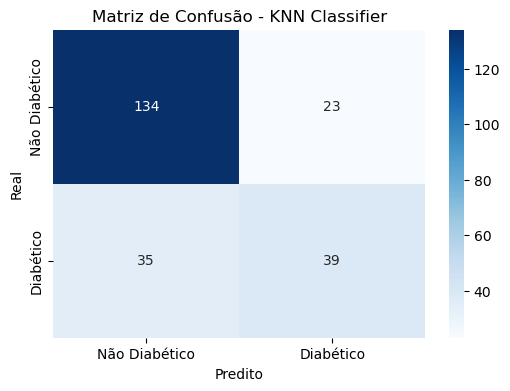

In [92]:
# Gerar o relatório de classificação
print(f"\n{name} - Relatório de Classificação:")
print(classification_report(y_test_diabetes, y_pred))
# Gerar o relatório de classificaçã
# Plotar a matriz de confusão
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Diabético', 'Diabético'], yticklabels=['Não Diabético', 'Diabético'])
plt.title(f'Matriz de Confusão - {name}')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()